In [2]:
!pip install -q ultralytics
from ultralytics import YOLO
import os
import shutil
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
import seaborn as sns
from PIL import Image
import torch
import numpy as np
import pandas as pd


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 58.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralyti

In [4]:
import zipfile

with zipfile.ZipFile("/content/Female or Male.v3i.yolov8.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [5]:
# ✅ Define dataset.yaml
dataset_yaml = """
path: /kaggle/input/female-or-male
train: /content/train/images
val: /content/valid/images
test: /content/test/images

names:
  0: female
  1: male
"""

with open("dataset.yaml", "w") as f:
    f.write(dataset_yaml)


In [6]:
# ✅ Load and train YOLOv8 model
model = YOLO("yolov8m.pt")  # or use yolov8s.pt etc.

results = model.train(
    data="dataset.yaml",
    epochs=50,
    imgsz=224,
    batch=32,
    name="yolov8_gender_classification",
    save=True,
    project="runs/detect"
)


100%|██████████| 49.7M/49.7M [00:01<00:00, 32.4MB/s]


Ultralytics 8.3.163 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_gender_classification, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pre

100%|██████████| 755k/755k [00:00<00:00, 102MB/s]

Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

 19                  -1  1   1327872  ultralytics.nn.modules.conv.Conv             [384, 384, 3, 2]              
 20             [-1, 9]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 21                  -1  2   4207104  ultralytics.nn.modules.block.C2f             [960, 576, 2]                 
 22        [15, 18, 21]  1   3776854  ultralytics.nn.modules.head.Detect           [2, [192, 384, 576]]          
Model summary: 169 layers, 25,857,478 parameters, 25,857,462 gradients, 79.1 GFLOPs

Transferred 469/475 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


...

      50/50      3.67G     0.4174     0.1984      0.952         30        224: 100%|██████████| 145/145 [00:28<00:00,  5.09it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.69it/s]

                   all        436        432      0.938       0.93      0.952      0.714



50 epochs completed in 0.443 hours.
Optimizer stripped from runs/detect/yolov8_gender_classification/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/yolov8_gender_classification/weights/best.pt, 52.0MB

Validating runs/detect/yolov8_gender_classification/weights/best.pt...
Ultralytics 8.3.163 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  1.94it/s]


                   all        436        432      0.925      0.952      0.957      0.726
                female        234        236      0.926      0.962      0.965      0.739
                  male        195        196      0.925      0.943      0.948      0.713
Speed: 0.1ms preprocess, 1.5ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to runs/detect/yolov8_gender_classification


In [7]:
# ✅ Save best.pt model to working directory
best_path = "runs/detect/yolov8_gender_classification/weights/best.pt"
if os.path.exists(best_path):
    shutil.copy(best_path, "/content/best.pt")
    print("✅ best.pt copied to content directory")
else:
    print("❌ best.pt not found, training might have failed")


✅ best.pt copied to content directory


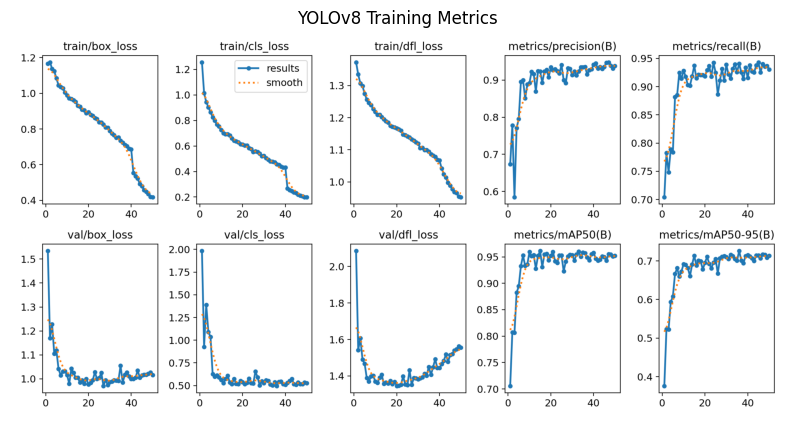

In [8]:
# ✅ Show training results.png from YOLO
def plot_metrics(results):
    metrics_path = os.path.join(results.save_dir, "results.png")
    if os.path.exists(metrics_path):
        img = Image.open(metrics_path)
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title("YOLOv8 Training Metrics")
        plt.show()
    else:
        print("❌ Training metrics image not found.")

plot_metrics(results)


In [9]:
# ✅ Evaluate on test set
metrics = model.val(data="dataset.yaml", split="test")


Ultralytics 8.3.163 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 417.9±151.2 MB/s, size: 9.5 KB)


val: Scanning /content/test/labels... 245 images, 5 backgrounds, 0 corrupt: 100%|██████████| 245/245 [00:00<00:00, 2289.01it/s]

val: New cache created: /content/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.86it/s]


                   all        245        243      0.937      0.941      0.961      0.722
                female        129        130      0.944      0.946      0.962      0.717
                  male        113        113       0.93      0.936       0.96      0.727
Speed: 0.2ms preprocess, 3.3ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to runs/detect/yolov8_gender_classification2


In [10]:
import os
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from ultralytics import YOLO

# --- Paths and setup ---
image_dir = "/content/test/images"
label_dir = "/content/test/labels"
label_map = {0: 'female', 1: 'male'}
y_true, y_pred = [], []

model = YOLO(best_path)

# --- Prediction loop ---
for file in os.listdir(image_dir):
    if file.endswith((".jpg", ".png", ".jpeg")):
        image_path = os.path.join(image_dir, file)
        label_path = os.path.join(label_dir, os.path.splitext(file)[0] + ".txt")

        # Skip if no label exists
        if not os.path.exists(label_path):
            continue

        # Read ground-truth class(es)
        with open(label_path, "r") as f:
            lines = f.readlines()
            for line in lines:
                class_id = int(line.strip().split()[0])
                y_true.append(class_id)

        # Predict with YOLO
        results = model(image_path, imgsz=224, conf=0.25)[0]
        if results.boxes is not None and len(results.boxes.cls) > 0:
            for c in results.boxes.cls:
                y_pred.append(int(c.item()))
        else:
            # If no face is detected, predict -1 or skip
            y_pred.append(-1)

# --- Remove mismatches if any ---
if len(y_true) != len(y_pred):
    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]

# --- Evaluation ---
if len(y_true) > 0:
    print("✅ Evaluation Summary:")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, labels=[0,1], average='macro'):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, labels=[0,1], average='macro'):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, labels=[0,1], average='macro'):.4f}")
else:
    print("❌ No valid predictions or labels.")



image 1/1 /content/test/images/1-6650-_jpg.rf.1b883c453f613e518dd05a43d30ba79d.jpg: 224x224 1 female, 17.4ms
Speed: 1.3ms preprocess, 17.4ms inference, 1.6ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/test/images/1-46-_jpeg.rf.289ec9652d577fdb7596d50c30fd5a2d.jpg: 224x224 1 female, 13.2ms
Speed: 0.9ms preprocess, 13.2ms inference, 3.2ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/test/images/1-2907-_jpg.rf.70c4db053c427ba1b01032dfd4f81466.jpg: 224x224 1 female, 13.3ms
Speed: 0.9ms preprocess, 13.3ms inference, 1.4ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/test/images/1-1357-_jpg.rf.0d9e1b60616c6db4cc38afc0e5c5b152.jpg: 224x224 1 male, 12.6ms
Speed: 0.8ms preprocess, 12.6ms inference, 1.3ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/test/images/1-6177-_jpg.rf.fc50c42cc20ca851a3fa8200061bdc00.jpg: 224x224 1 female, 14.3ms
Speed: 0.9ms preprocess, 14.3ms inference, 1.3ms postprocess per 

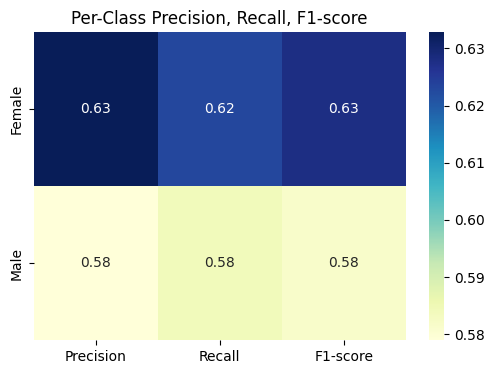

In [12]:
# ✅ Precision, Recall, F1 heatmap
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0,1])
df = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
}, index=['Female', 'Male'])

plt.figure(figsize=(6, 4))
sns.heatmap(df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Per-Class Precision, Recall, F1-score")
plt.show()



image 1/1 /content/test/images/1-6650-_jpg.rf.1b883c453f613e518dd05a43d30ba79d.jpg: 224x224 1 female, 14.5ms
Speed: 0.9ms preprocess, 14.5ms inference, 2.4ms postprocess per image at shape (1, 3, 224, 224)


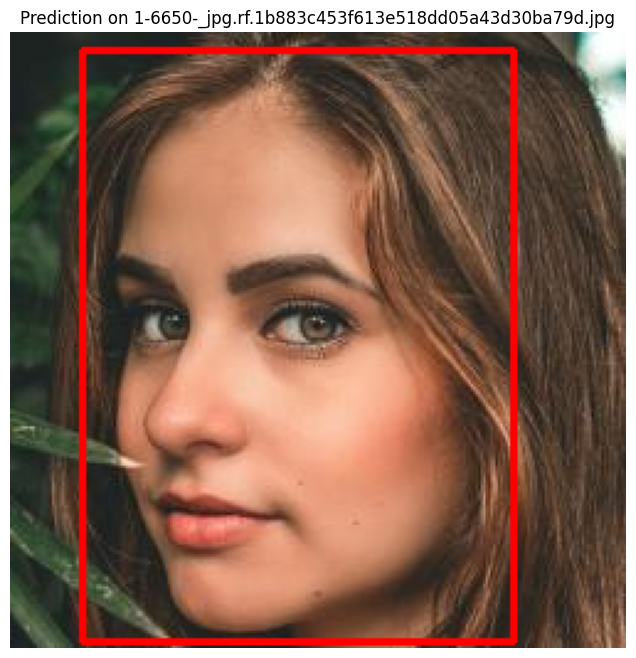


image 1/1 /content/test/images/1-46-_jpeg.rf.289ec9652d577fdb7596d50c30fd5a2d.jpg: 224x224 1 female, 13.4ms
Speed: 1.0ms preprocess, 13.4ms inference, 2.1ms postprocess per image at shape (1, 3, 224, 224)


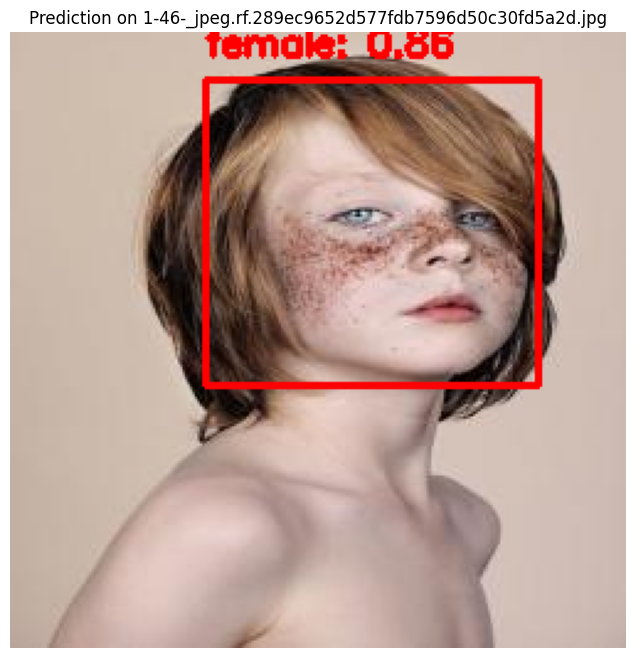


image 1/1 /content/test/images/1-2907-_jpg.rf.70c4db053c427ba1b01032dfd4f81466.jpg: 224x224 1 female, 17.0ms
Speed: 1.1ms preprocess, 17.0ms inference, 2.0ms postprocess per image at shape (1, 3, 224, 224)


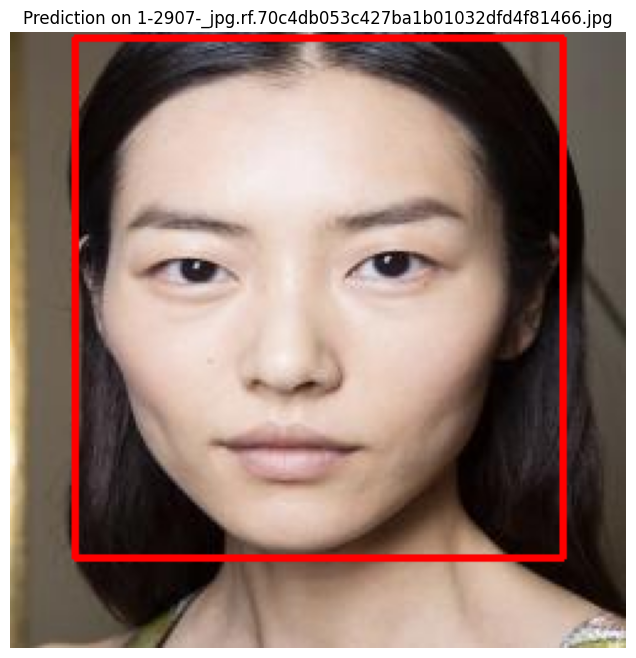


image 1/1 /content/test/images/1-1357-_jpg.rf.0d9e1b60616c6db4cc38afc0e5c5b152.jpg: 224x224 1 male, 22.1ms
Speed: 1.0ms preprocess, 22.1ms inference, 2.1ms postprocess per image at shape (1, 3, 224, 224)


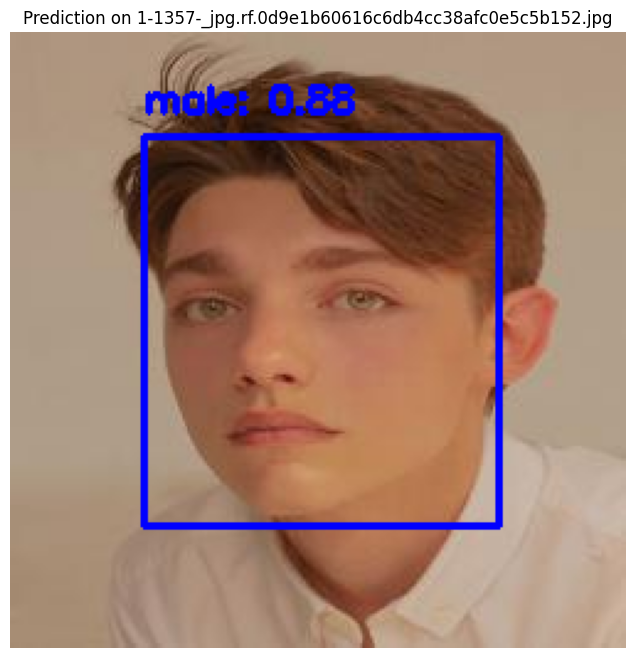


image 1/1 /content/test/images/1-6177-_jpg.rf.fc50c42cc20ca851a3fa8200061bdc00.jpg: 224x224 1 female, 18.3ms
Speed: 1.0ms preprocess, 18.3ms inference, 1.8ms postprocess per image at shape (1, 3, 224, 224)


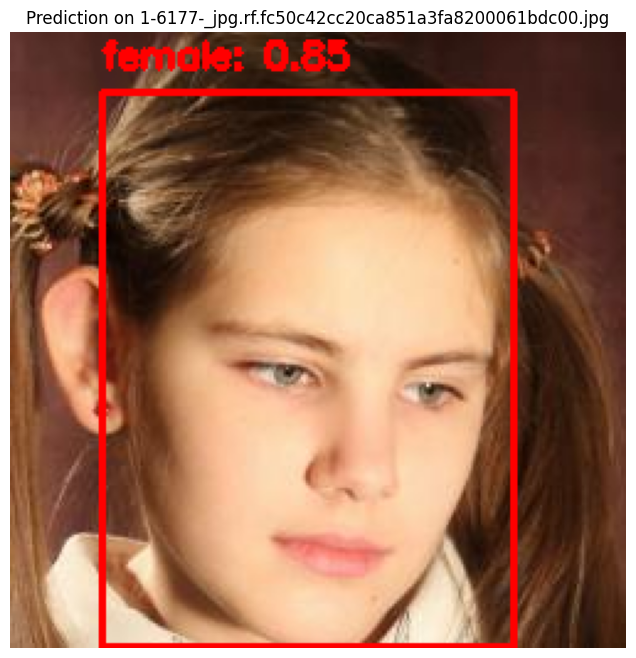


image 1/1 /content/test/images/1-331-_jpg.rf.69add1bad6f87bc2334f47b6113981bc.jpg: 224x224 1 male, 14.3ms
Speed: 1.2ms preprocess, 14.3ms inference, 2.2ms postprocess per image at shape (1, 3, 224, 224)


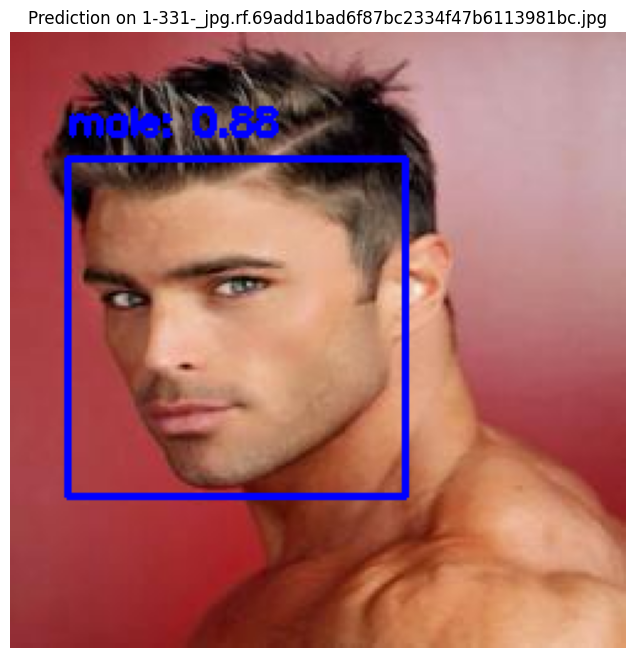


image 1/1 /content/test/images/1-2380-_jpg.rf.a62b9cee5038514dfb8d4ddff5fed017.jpg: 224x224 1 male, 14.8ms
Speed: 1.0ms preprocess, 14.8ms inference, 2.1ms postprocess per image at shape (1, 3, 224, 224)


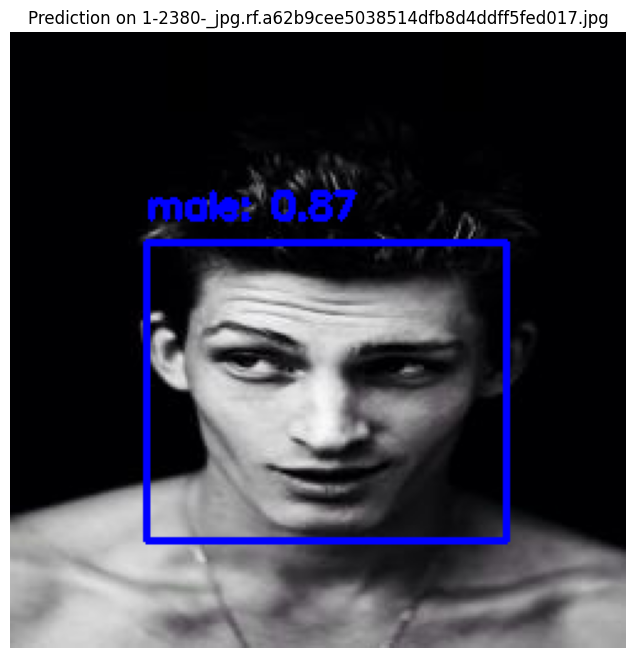


image 1/1 /content/test/images/1-3964-_jpg.rf.e3449b24b1fa208340ef49754a3c1eb7.jpg: 224x224 1 female, 15.2ms
Speed: 1.0ms preprocess, 15.2ms inference, 2.4ms postprocess per image at shape (1, 3, 224, 224)


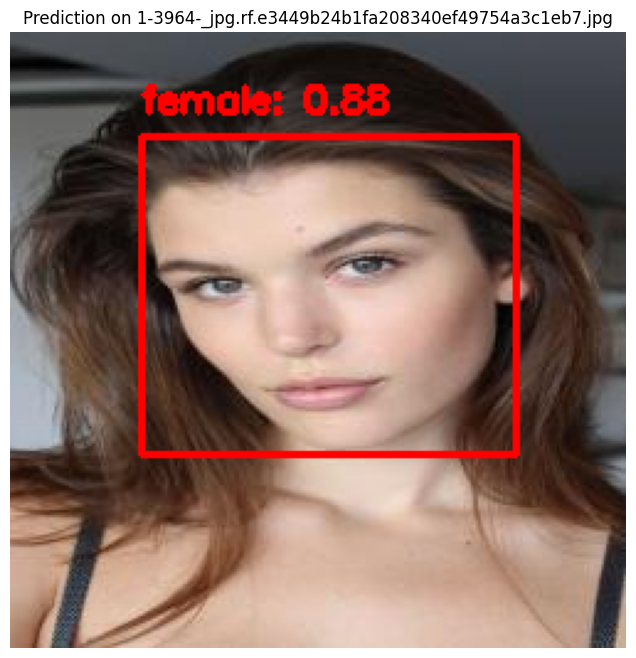


image 1/1 /content/test/images/1-6749-_jpg.rf.c5450f54395a6f6aa590919e2c6cd4f3.jpg: 224x224 1 female, 20.6ms
Speed: 1.1ms preprocess, 20.6ms inference, 5.8ms postprocess per image at shape (1, 3, 224, 224)


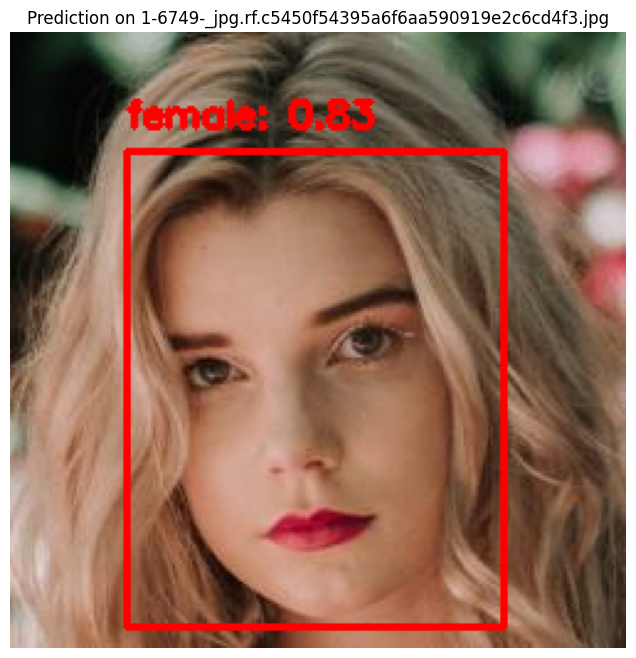


image 1/1 /content/test/images/1-4618-_jpg.rf.30c138cfa7d5469ae346c50b70297250.jpg: 224x224 1 female, 21.5ms
Speed: 3.8ms preprocess, 21.5ms inference, 2.3ms postprocess per image at shape (1, 3, 224, 224)


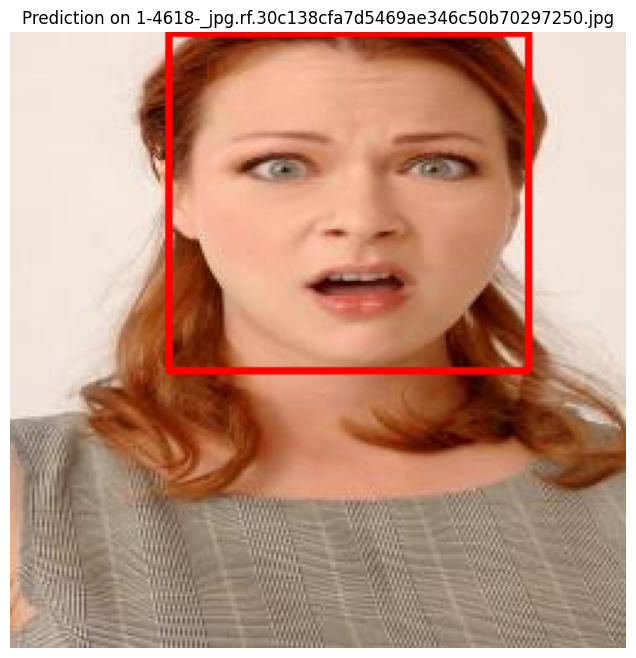

In [14]:
from IPython.display import display
import cv2

# Get list of test images
test_images = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith((".jpg", ".png", ".jpeg"))]

# Process and display a few test images
num_images_to_display = 10
for image_path in test_images[:num_images_to_display]:
    # Read image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Perform inference
    results = model(image_path, imgsz=224, conf=0.25)[0]

    # Draw bounding boxes and labels
    if results.boxes is not None and len(results.boxes.cls) > 0:
        for box in results.boxes:
            x1, y1, x2, y2 = [int(i) for i in box.xyxy[0]]
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            label = f"{label_map[class_id]}: {confidence:.2f}"

            # Draw box and label
            color = (255, 0, 0) if class_id == 0 else (0, 0, 255) # Red for female, Blue for male
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img_rgb, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # Display image
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Prediction on {os.path.basename(image_path)}")
    plt.show()